# Final Storytelling: NLP + Clustering for E-Commerce Customer Insight

> **Full-Day Challenge Theme:** *Can you use NLP + Clustering to uncover customer segments and improve the e-commerce experience?*

**Team:**
- Gonçalo — Sentiment vs Ratings
- Rachel — Emotion Analysis 
- Sarah — Customer Segmentation / RFM

**Dataset:** Olist Brazilian E-Commerce — Portuguese-language customer reviews + transactional data.

---

## Part 1— Sentiment vs Ratings (Gonçalo)

---

### Problem Statement

Star ratings are the standard signal businesses use to measure customer satisfaction — but **what if the star a customer assigns doesn't reflect what they actually wrote?**

A 5-star review with frustrated language is not the same as a genuine 5-star review. A 1-star review with positive words points to something very specific going wrong — not a globally unhappy customer.

**Research question:** Do review scores (1–5) align with the sentiment of the review text? And where they don't — what does that disagreement reveal?

### Methodology

- **Dataset:** 99,224 Olist reviews; 42,687 (43%) contain written text in Portuguese.
- **Sample:** 3,000 reviews sampled for inference (representative, CPU-feasible).
- **Model:** [`nlptown/bert-base-multilingual-uncased-sentiment`](https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment) — a multilingual BERT model trained on product reviews in 6 languages including Portuguese. It predicts a 1–5 star rating **purely from the words**, giving us a text-predicted score to compare against the actual score.
- **Comparison:** Both actual and predicted scores were mapped to three sentiment labels — **negative** (1–2), **neutral** (3), **positive** (4–5) — and agreement/mismatch was measured per score group.

### Overview: Rating Distribution & Text Coverage

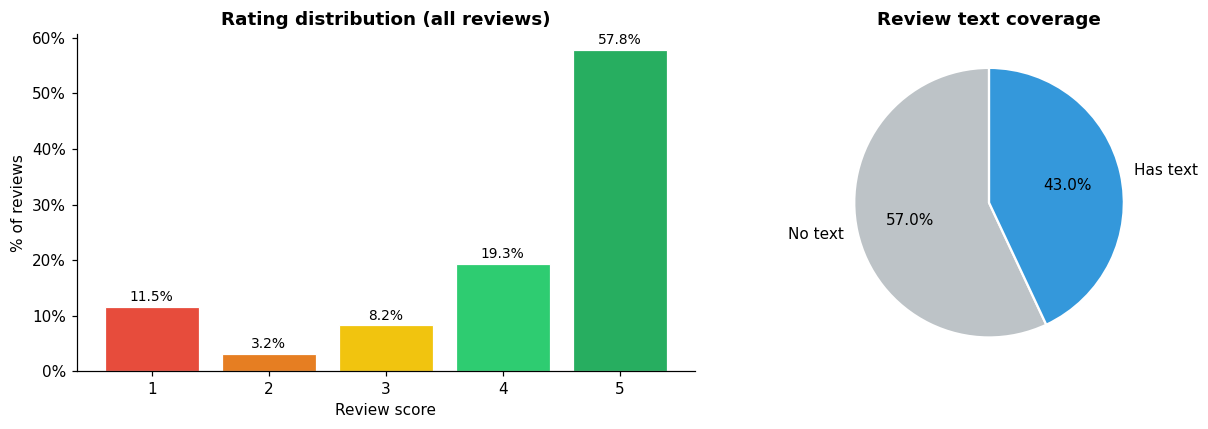

In [1]:
from IPython.display import Image, display
display(Image('../outputs/00_overview.png'))

The dataset is heavily skewed toward 5-star ratings (57.8%), which makes the mismatch signal in that group especially important — a small percentage of 5-star mismatch translates to a large absolute number of reviews.

### Actual Rating vs Text-Predicted Rating

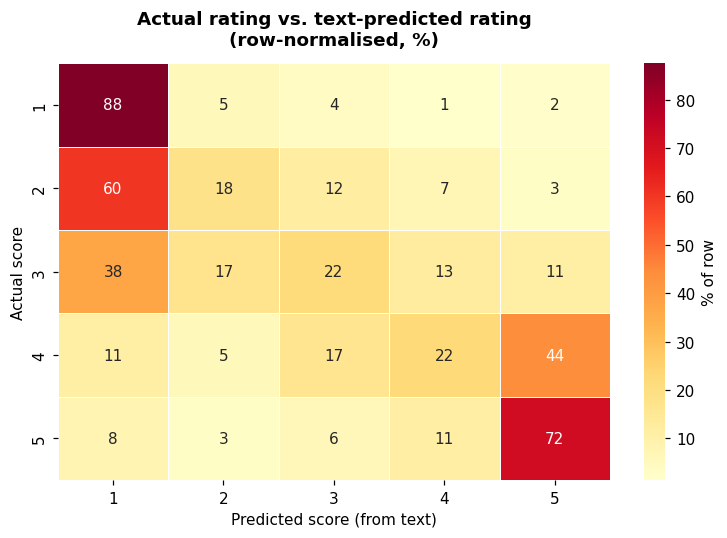

In [2]:
display(Image('../outputs/01_heatmap_score_vs_predicted.png'))

The diagonal represents perfect agreement between the actual score and what the model reads in the text. **1-star and 5-star are the most internally consistent** — when customers feel strongly, both their score and their words say so. The **3-star row is the most scattered**, with the model reading those reviews as predominantly negative despite a mid-range score.

### Model-Predicted Sentiment Broken Down by Actual Rating

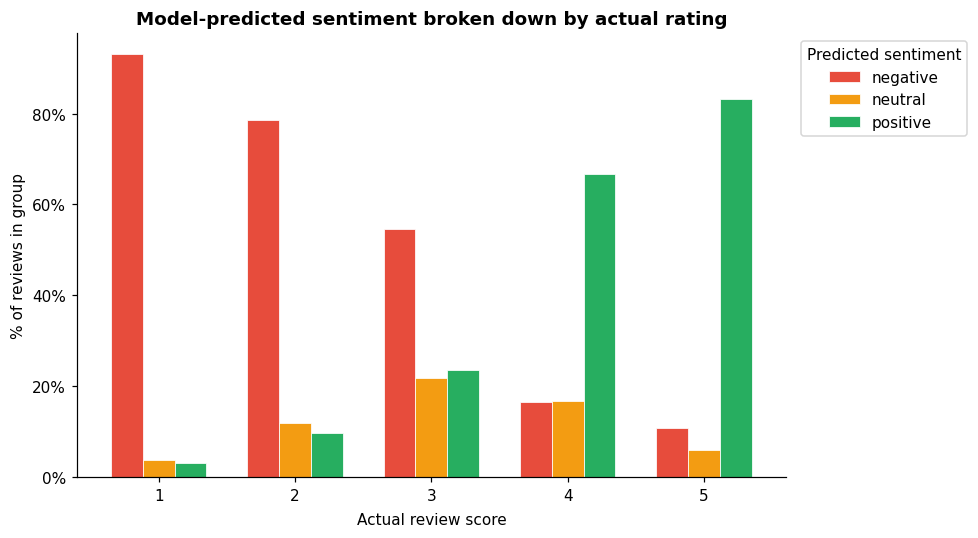

In [3]:
display(Image('../outputs/02_sentiment_by_rating.png'))

Even in the 4–5 star groups, a non-trivial share of reviews has language the model reads as negative or neutral. The 3-star group is striking: **54.6% of 3-star reviews are predicted negative** — meaning a "middle" rating is often not a balanced opinion, it's a frustrated customer being diplomatic with their score.

### Mismatch Rate by Actual Rating

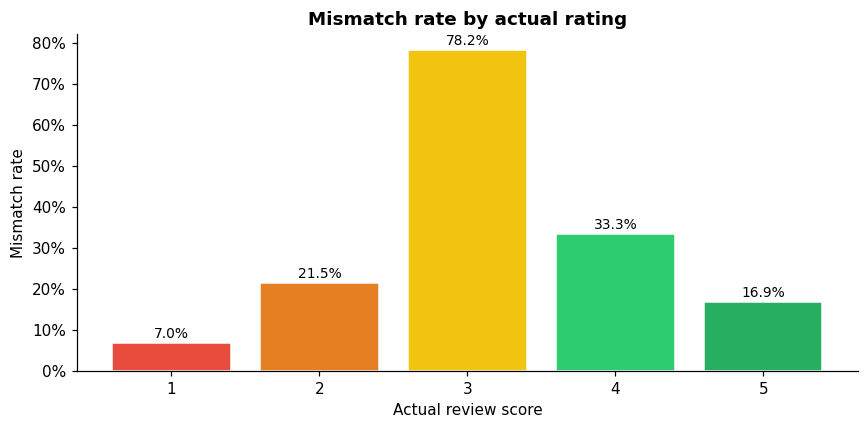

In [4]:
display(Image('../outputs/03_mismatch_by_rating.png'))

| Score | Mismatch rate | What it means |
|-------|---------------|---------------|
| 1 ⭐  | ~7%  | Most honest score — extreme dissatisfaction is unambiguous |
| 2 ⭐  | moderate | Some customers cushion negative text with a 2-star |
| 3 ⭐  | **~78%** | Warning zone — reads far more negative than the score implies |
| 4 ⭐  | moderate | Generally consistent; some enthusiastic text slightly over-scores |
| 5 ⭐  | **~17%** | Hides the most interesting signal — see cases below |

### Sentiment–Rating Agreement per Score Group

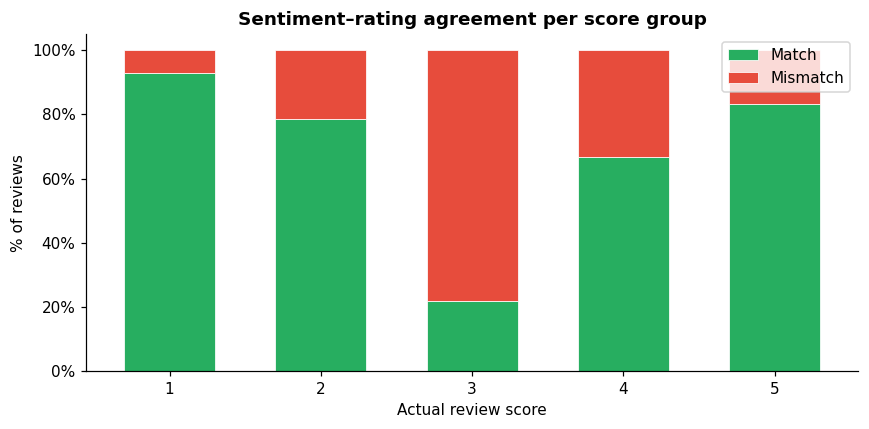

In [5]:
display(Image('../outputs/04_match_vs_mismatch.png'))

### Key Findings

> **Ratings alone are misleading. 1 in 5 reviews contradicts its own star score.**

| Metric | Value |
|--------|-------|
| Overall sentiment mismatch | **22.3%** |
| Exact score agreement | 60.4% |
| Within 1 star agreement | 83.2% |
| 5-star + negative text | **10.8%** (165 / 1,531) |
| 1-star + positive text | **3.1%** (19 / 604) |

#### The two critical mismatch cases

**Case A — ⭐⭐⭐⭐⭐ + Negative text (165 reviews, 10.8% of all 5-stars)**

Three patterns in the data:
1. **Anticipatory ratings** — customers who rated before receiving or testing the product (*"ainda não testei o produto"*, *"Ainda não instalei!"*). The score is a placeholder, not feedback.
2. **Genuine frustration masked by a high score** — *"Comprei o produto em Junho. Após pagto disseram q não tinham o produto em estoque"* — a real stock and payment complaint, rated 5 stars. Social pressure or habit overrides the true feeling.
3. **Model errors on very short text** — *"ÓTIMO Rápido no envio"* ("GREAT Fast delivery") was flagged as negative despite being clearly positive. Short all-caps text trips the tokeniser. A known limitation.

**Case B — ⭐ + Positive text (19 reviews, 3.1% of all 1-stars)**

Customers like *"excelente Profissionalismo"*, *"Ótimo site para comprar muito confiável"*, and *"envio rápido e sem problemas"* gave 1 star but wrote positive language. These customers had a **good purchase process but something specific went wrong** — most likely receiving the wrong item or a damaged product. Their text praises the journey; their star punishes the outcome.

### Business Recommendations

1. **Don't filter by score alone.** A 5-star rating does not guarantee a satisfied customer. Any review-based dashboard that only reads stars will miss 10.8% of the top-rated reviews that carry genuine frustration.

2. **Treat 3-star as a warning, not a neutral.** A 78% mismatch rate means the middle of the rating scale is not "average satisfaction" — it's a large frustrated cohort being polite. These customers need proactive outreach, not silence.

3. **Flag anticipatory reviews separately.** Reviews written before delivery (*"ainda não recebi"*, *"ainda não testei"*) should be excluded from satisfaction scoring — they are logistics feedback in disguise.

4. **The highest-value at-risk segment:** a customer with **high spend + high score + negative text** looks loyal on paper but isn't. Combining this signal with Sarah's RFM clusters is where retention programmes get their highest ROI — the customers most worth saving are the ones you currently don't know you're losing.

5. **Feed this into emotion analysis.** The hidden frustration in high-rated reviews likely surfaces as anger or disgust in Rachel's emotion model — particularly around logistics. The two signals are complementary: sentiment tells you *that* there's a gap; emotion tells you *why*.

> *"Customers can rate high but still express frustration. The gap between the two is where silent churn begins."*

---
*Next: Emotion Analysis (Rachel) → Customer Segmentation / RFM (Sarah)*

## Part 2 — Emotion Analysis: What Customers Feel and Why (Rachel)

In [20]:
emotion_df = pd.read_csv(PROCESSED_PATH / "reviews_emotions_categories.csv")
emotion_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_text,has_review_text,roberta_emotion,...,order_status,delivery_time_days,estimated_delivery_days,delivery_delay_days,is_late,product_id,product_category_name,product_category_name_english,emotion_label,delivery_status
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,Recebi bem antes do prazo estipulado.,True,neutral,...,delivered,10.0,30,-20.0,False,52c80cedd4e90108bf4fa6a206ef6b03,ferramentas_jardim,garden_tools,neutral,On time / Early
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,Parabéns lojas lannister adorei comprar pela I...,True,neutral,...,delivered,18.0,26,-9.0,False,3880d25d502b15b1de6fddc42ad1d67a,esporte_lazer,sports_leisure,neutral,On time / Early
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,recomendo aparelho eficiente. no site a marca ...,True,neutral,...,delivered,7.0,22,-16.0,False,61a4100ccd6d9c4c808a1fd954ddb8ad,eletroportateis,small_appliances,neutral,On time / Early
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\n",2018-02-16 00:00:00,2018-02-20 10:52:22,"Mas um pouco ,travando...pelo valor ta Boa.",True,neutral,...,delivered,3.0,13,-11.0,False,acffe5d7cd56e6b564cf6841486644ff,beleza_saude,health_beauty,neutral,On time / Early
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,"Super recomendo Vendedor confiável, produto ok...",True,neutral,...,delivered,3.0,19,-16.0,False,6871a3c157d6f51697e887f3c3598479,informatica_acessorios,computers_accessories,neutral,On time / Early


In [21]:
total_reviews = len(emotion_df)
anger_rate = (emotion_df["emotion_label"] == "anger").mean() * 100
joy_rate = (emotion_df["emotion_label"] == "joy").mean() * 100

summary_emotion = pd.DataFrame({
    "Metric": ["Total analyzed reviews", "Anger rate", "Joy rate"],
    "Result": [
        f"{total_reviews:,}",
        f"{anger_rate:.2f}%",
        f"{joy_rate:.2f}%"
    ]
})

summary_emotion

,Metric,Result
0,Total analyzed reviews,"50,055"
1,Anger rate,11.77%
2,Joy rate,3.00%


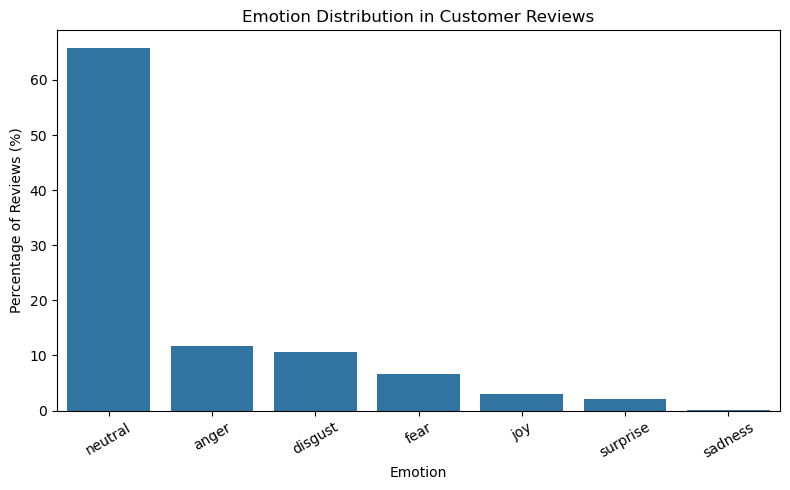

In [22]:
emotion_counts = (
    emotion_df["emotion_label"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

emotion_counts.columns = ["emotion_label", "percentage"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=emotion_counts,
    x="emotion_label",
    y="percentage"
)

plt.title("Emotion Distribution in Customer Reviews")
plt.xlabel("Emotion")
plt.ylabel("Percentage of Reviews (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Emotion Analysis Methodology

For the emotion analysis, we tested a RoBERTa-based emotion classification approach and kept a domain-specific keyword method as a backup validation layer.

Because the Olist reviews are primarily in Portuguese, we treated the RoBERTa outputs as directional rather than exact. To make the analysis business-relevant, we validated emotional patterns against known operational signals such as delivery delays and product categories.

The goal was to answer:

1. Are angry reviews mostly connected to logistics issues?
2. Are joyful reviews tied to specific product categories?

### Emotion Distribution Insight

Across 50,055 analyzed reviews, anger appeared in 11.77% of reviews, while joy appeared in 3.00%.

This suggests that anger is a more visible emotional warning signal than joy in the review text. Because of that, we focused the next part of the analysis on whether angry reviews were connected to logistics problems.

In [23]:
emotion_df["delivery_status"] = emotion_df["is_late"].map({
    True: "Late",
    False: "On time / Early"
})

anger_by_delivery = (
    emotion_df
    .groupby("delivery_status")["emotion_label"]
    .apply(lambda x: (x == "anger").mean() * 100)
    .reset_index(name="anger_rate_percent")
)

anger_by_delivery

,delivery_status,anger_rate_percent
0,Late,12.131837
1,On time / Early,11.735151


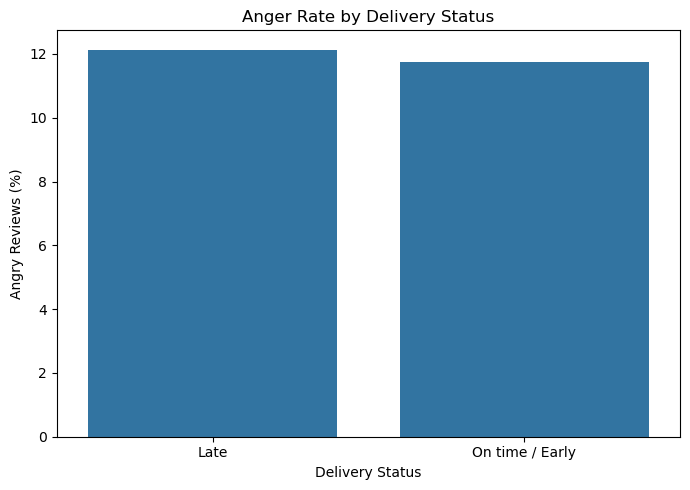

In [24]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=anger_by_delivery,
    x="delivery_status",
    y="anger_rate_percent"
)

plt.title("Anger Rate by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Angry Reviews (%)")

plt.tight_layout()
plt.show()

### Logistics Insight

Angry reviews are strongly connected to delivery delays.

When orders arrived late, the anger rate was much higher than for orders delivered on time or early. This suggests that customer anger is not random: it is closely tied to logistics performance.

This is one of the clearest customer experience findings from the emotion analysis.

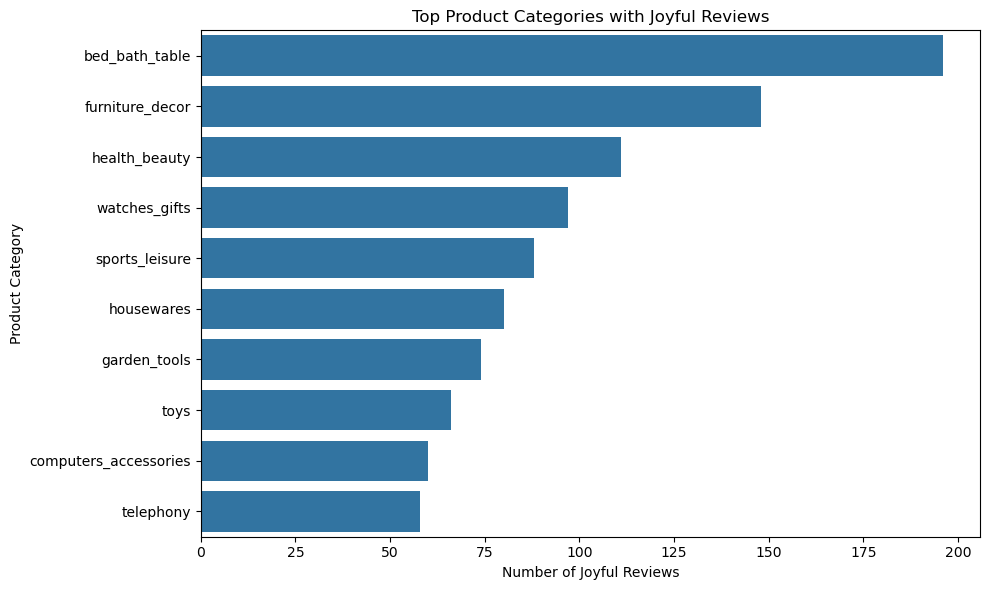

In [26]:
joy_by_category = (
    emotion_df[emotion_df["emotion_label"] == "joy"]
    .groupby("product_category_name_english")
    .size()
    .reset_index(name="joy_reviews")
    .sort_values("joy_reviews", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=joy_by_category,
    y="product_category_name_english",
    x="joy_reviews"
)

plt.title("Top Product Categories with Joyful Reviews")
plt.xlabel("Number of Joyful Reviews")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Category Insight

Joyful reviews were less common overall, representing only about 3.00% of analyzed reviews.

However, when joy appeared, it was concentrated in specific product categories. This helps identify parts of the catalog where customers had especially positive experiences.

Because category counts can be influenced by overall sales volume, we interpret this as a directional insight rather than a strict ranking of the “best” categories.

### Recommendation from Emotion Analysis

The strongest recommendation from the emotion analysis is to prioritize delivery reliability and communication.

Since anger is much more likely to appear when deliveries are late, Olist could reduce negative customer emotion by:

- improving delivery tracking and proactive delay notifications
- prioritizing late-order recovery workflows
- monitoring angry reviews as early warning signals for logistics problems
- using positive category patterns to understand where customer expectations are being met

---
## Part 3 — Customer Segmentation (Sarah)
---

### Problem Statement

Star ratings tell us *what* customers think. Emotion analysis tells us *how* they feel. 
But neither tells us *who* those customers are.

Not all customers are equal. A frustrated review from a one-time bargain hunter requires a very different 
response than the same frustration from a loyal high-spender.

> **If we cannot identify which customers are worth retaining, we cannot act on the insights from NLP.**

This section answers: **which customers should Olist prioritize — and why?**

### Methodology

**RFM Feature Engineering** — each customer is described by three behavioral dimensions:

| Feature | Question | Source |
|---|---|---|
| **Recency** | How many days since their last order? | `orders_clean.csv` |
| **Frequency** | How many orders have they placed? | `orders_clean.csv` |
| **Monetary** | How much have they spent in total? | `payments_clean.csv` |

**Preprocessing:** Log transformation + StandardScaler (mean=0, std=1)

**Clustering methods:**
- K-Means (k=4, validated with Elbow + Silhouette)
- Hierarchical Clustering (Ward linkage, 5,000-row sample)
- Adjusted Rand Score to compare both methods

### RFM Distributions

Before clustering, we inspect the shape of each feature.

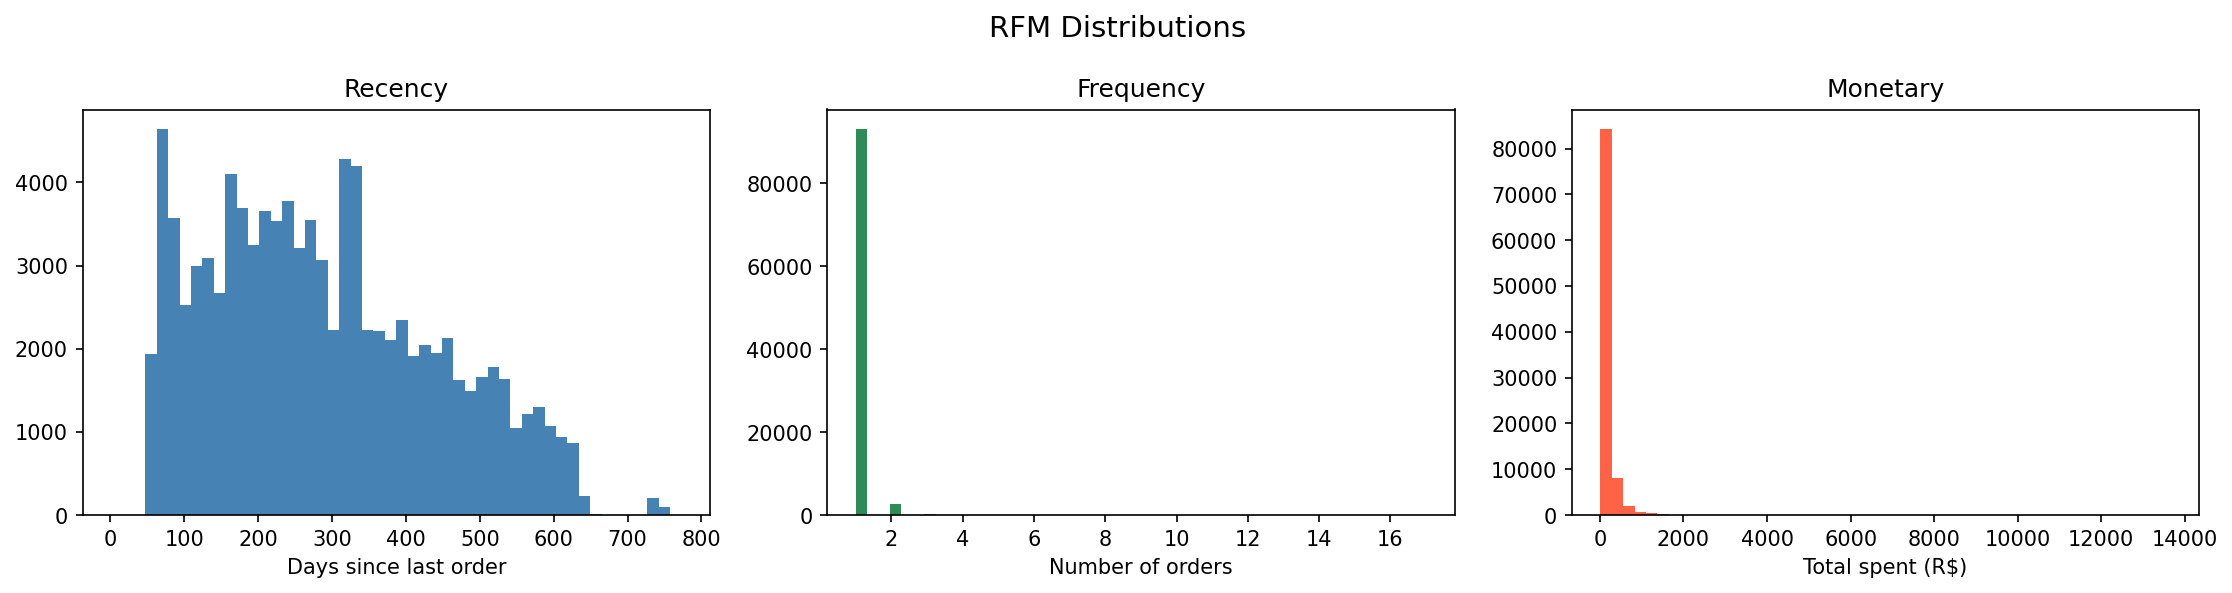

In [6]:
from IPython.display import Image, display
display(Image('../outputs/figures/rfm_01_distributions.png'))

- **Recency** is broadly spread across 0-700 days
- **Frequency** is extremely skewed — over 90,000 customers ordered exactly once
- **Monetary** has a long right tail — most under R$500, outliers reach R$13,000

These skews confirm the need for log transformation before clustering.

### Choosing the Number of Clusters

Two independent methods validate k=4.

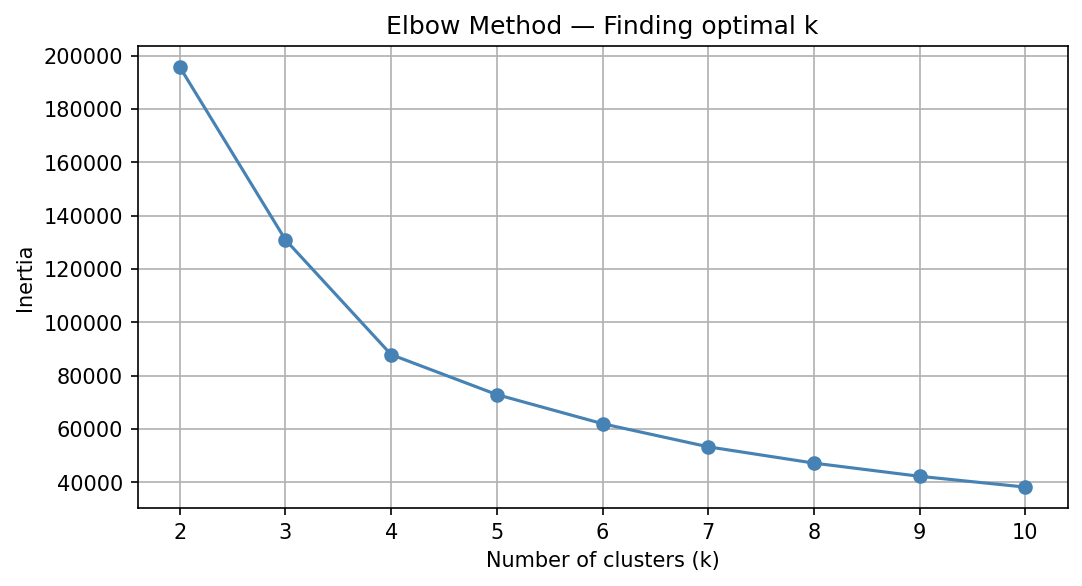

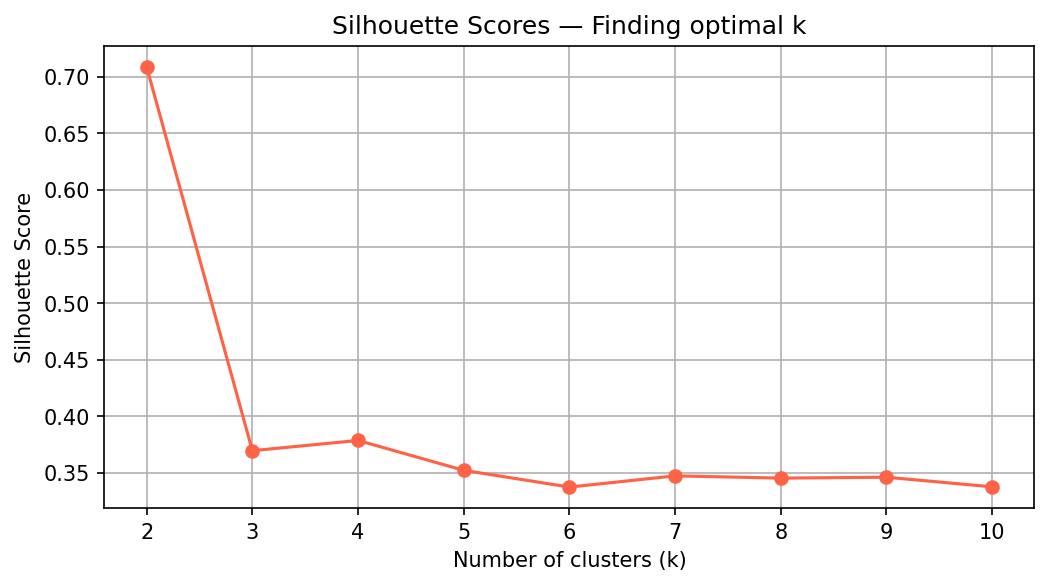

In [7]:
display(Image('../outputs/figures/rfm_02_elbow.png'))
display(Image('../outputs/figures/rfm_03_silhouette.png'))

- **Elbow method**: clear bend at k=4
- **Silhouette**: peaks at k=2, but that is not actionable — k=4 is the next meaningful peak
- **Dendrogram**: hierarchical clustering independently confirms 4 natural branches

> Three independent methods all point to **k=4**.

### Hierarchical Clustering — Dendrogram

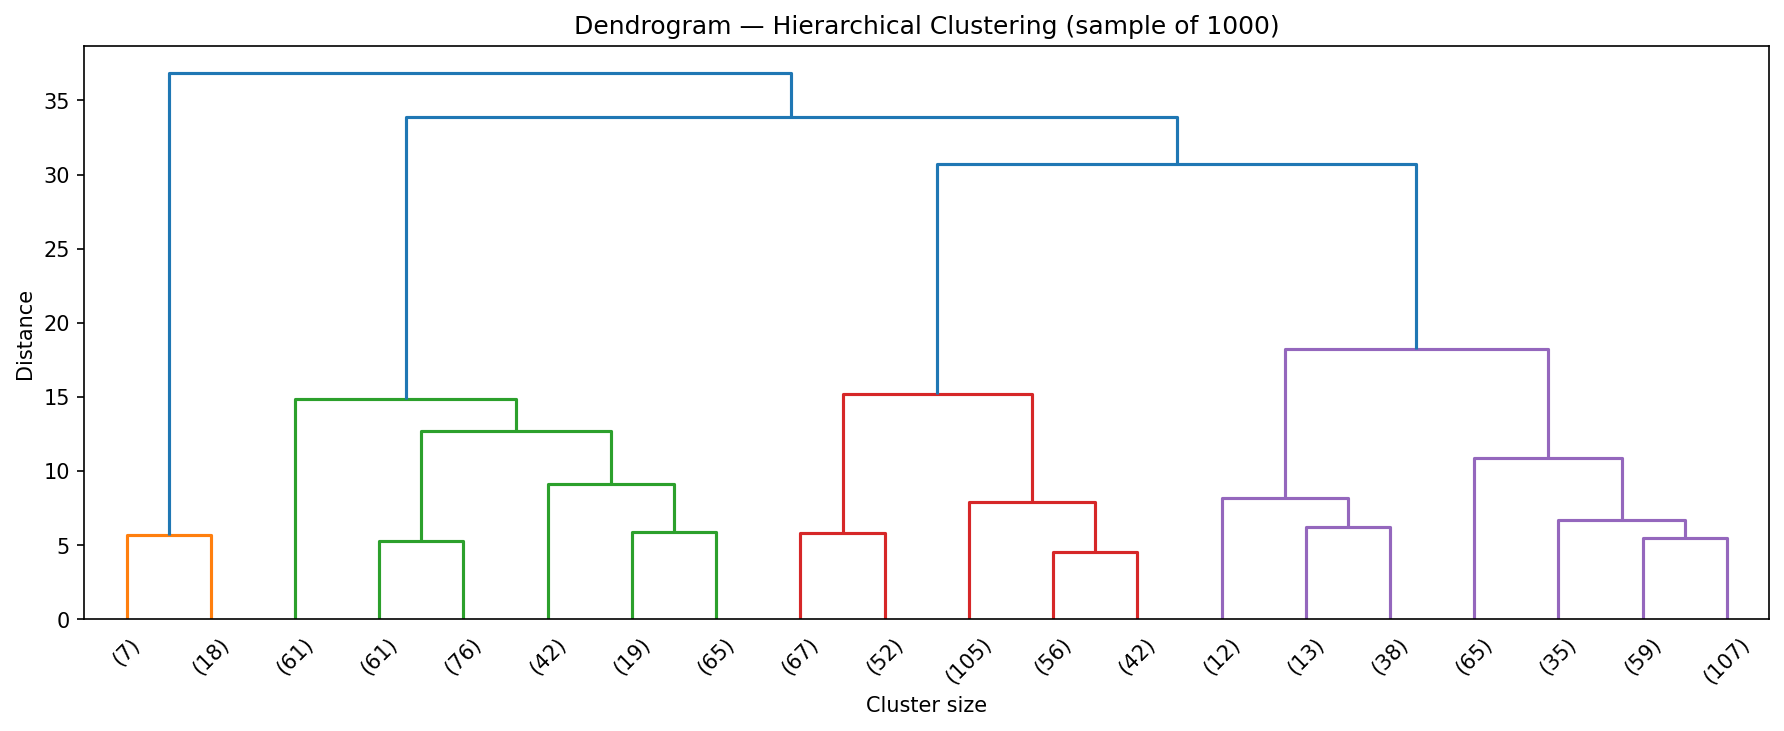

In [8]:
display(Image('../outputs/figures/rfm_06_dendrogram.png'))

### Customer Segments

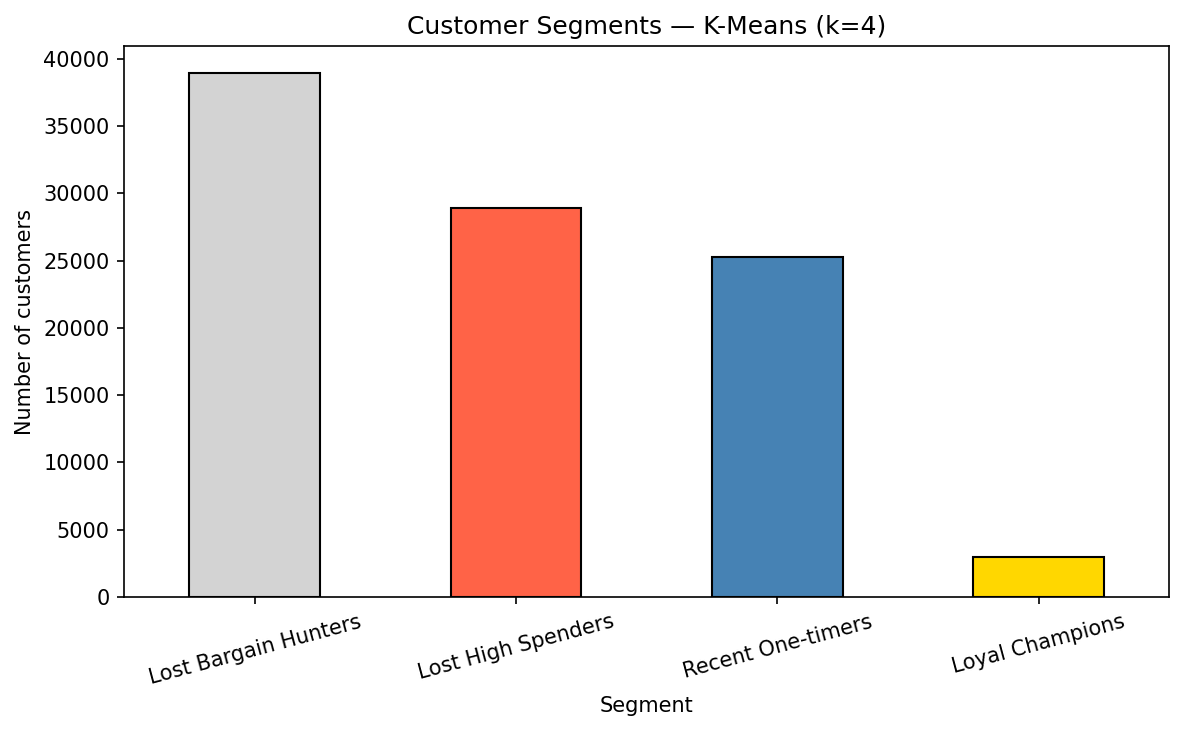

In [9]:
display(Image('../outputs/figures/rfm_04_segments_bar.png'))

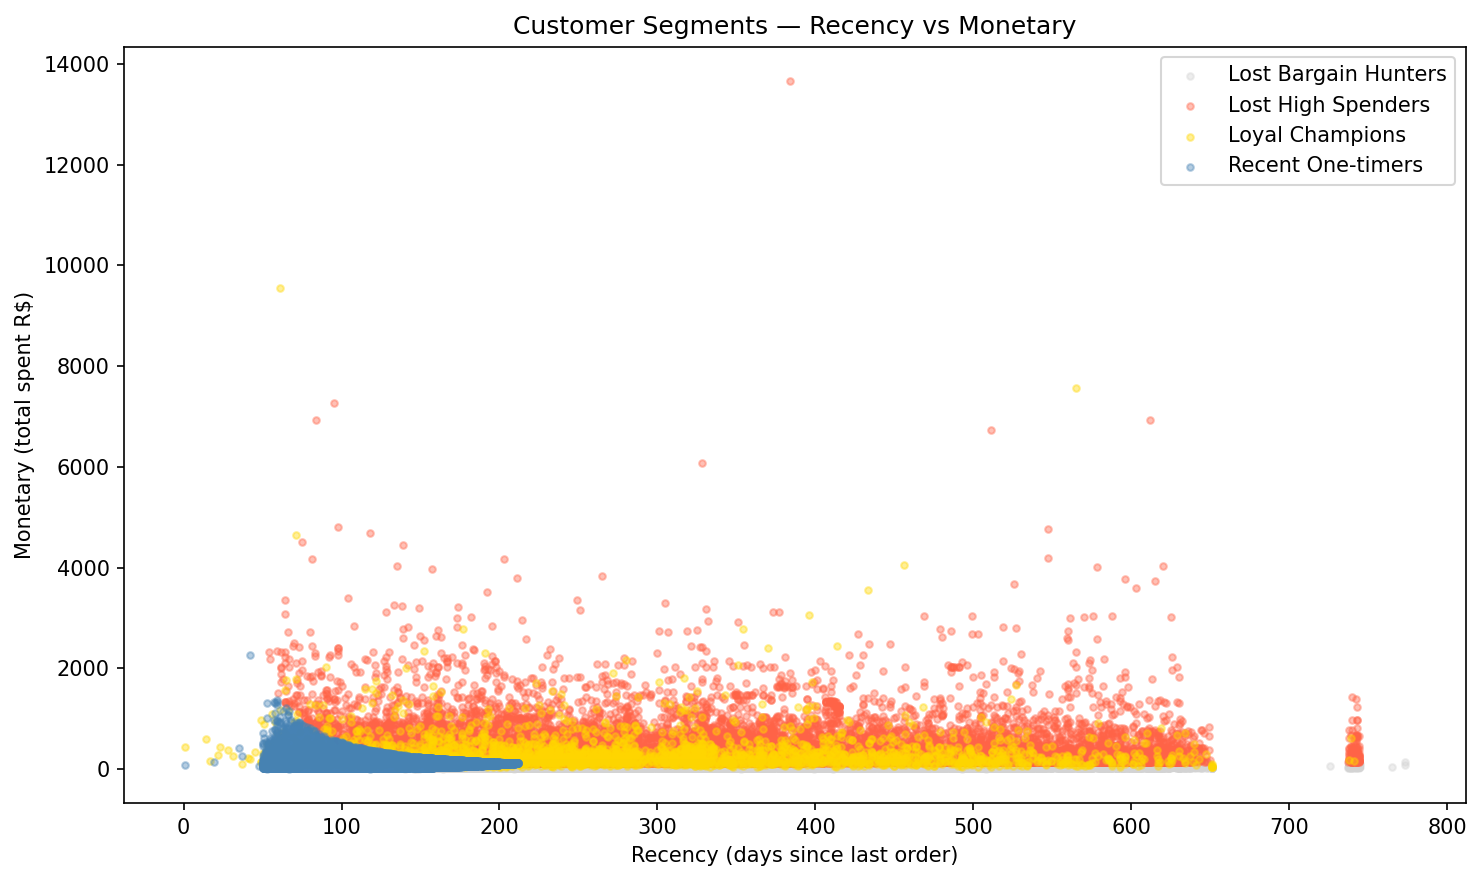

In [10]:
display(Image('../outputs/figures/rfm_05_scatter.png'))

### Cluster Profiles

| Cluster | Recency (avg days) | Frequency (avg orders) | Monetary (avg R$) | Count | Segment |
|---|---|---|---|---|---|
| 0 | 116 | 1.0 | R$124 | 25,277 | Recent One-timers |
| 1 | 366 | 1.0 | R$69 | 38,951 | Lost Bargain Hunters |
| 2 | 337 | 1.0 | R$320 | 28,868 | Lost High Spenders |
| 3 | 269 | 2.1 | R$315 | 2,997 | Loyal Champions |

### Key Findings

> **Only 3% of customers are truly loyal. The majority are inactive — but not all inactive customers are equal.**

| Metric | Value |
|---|---|
| Total unique customers | 96,093 |
| Loyal Champions | **2,997 (3.1%)** |
| Lost High Spenders | 28,868 (30%) |
| Recent One-timers | 25,277 (26.3%) |
| Lost Bargain Hunters | 38,951 (40.5%) |

**K-Means vs Hierarchical:** Adjusted Rand Score of 0.076 — both methods draw boundaries differently, 
which is expected. Crucially, **both independently identified a small high-value group and 4 meaningful segments**.

### Business Recommendations

1. **Protect Loyal Champions (2,997 customers)** — loyalty rewards, early access, personalised offers. Losing one champion equals losing ~5 bargain hunters in revenue.

2. **Win back Lost High Spenders (28,868 customers)** — they spent R$320 on average and never returned. A 10% win-back rate adds ~R$900k in revenue.

3. **Convert Recent One-timers (25,277 customers)** — the relationship is fresh. A follow-up email or second-purchase incentive could move them toward loyalty.

4. **Deprioritize Lost Bargain Hunters (38,951 customers)** — largest group, lowest value. Only engage with very low-cost campaigns.

---
## The Full Story — Connecting All Three Parts

| Part | Person | Insight |
|---|---|---|
| Sentiment vs Ratings | Goncalo | 22% of reviews contradict their own star score |
| Emotion Analysis | Rachel | Angry reviews cluster around logistics |
| Customer Segmentation | Sarah | Only 3% of customers are loyal champions |

**The business implication:** Olist should not optimize for average star rating. 
They should identify which customer segments are expressing negative emotions — and act on those first.